In [5]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd

# 1. 데이터 준비 (네 데이터프레임 변수명이 df_officetel_officetel라고 가정할게)
df_officetel = pd.read_csv("/home/heartsping/SKN23-FINAL-1team/ml_research/processed_data/officetel_processed_items_data_2026-04-22.csv")
df_officetel = df_officetel.dropna(subset = ["room_direction"])
del df_officetel["manage_cost"]

# 결측치 처리
df_officetel = df_officetel.dropna(subset=['converted_monthly_rent'])
df_officetel.fillna(df_officetel.median(numeric_only=True), inplace=True)

# 이상치 제거
Q1 = df_officetel['converted_monthly_rent'].quantile(0.01)
Q3 = df_officetel['converted_monthly_rent'].quantile(0.99)
df_officetel = df_officetel[(df_officetel['converted_monthly_rent'] >= Q1) & (df_officetel['converted_monthly_rent'] <= Q3)]
df_officetel = df_officetel[(df_officetel['area_m2'] > 0) & (df_officetel['area_m2'] < 200)]
df_officetel = df_officetel[(df_officetel['building_age'] >= 0) & (df_officetel['building_age'] < 100)]

print(f"이상치 제거 후: {df_officetel.shape}")

# X는 피처(특성), y는 타겟(적정 금액)
X_officetel = df_officetel.drop('converted_monthly_rent', axis=1)
y_officetel = df_officetel['converted_monthly_rent']

# 2. ★ 중요 ★ 범주형 컬럼 이름 리스트 만들기
# 지역, 아파트 이름, 지하철역 같은 글자로 된 컬럼들을 여기 다 적어줘.
cat_features = ["room_type", "room_direction", "district", "contract_class"]

# 3. 데이터 분할
X_officetel_train, X_officetel_test, y_officetel_train, y_officetel_test = train_test_split(X_officetel, y_officetel, test_size=0.2, random_state=42)

# 4. 모델 생성
model_officetel = CatBoostRegressor(
    iterations=1000,          # 학습 반복 횟수
    learning_rate=0.1,        # 학습률 (너무 크면 휙휙 지나가고 너무 작으면 한 세월이야)
    depth=6,                  # 트리의 깊이
    cat_features=cat_features, # 범주형 피처 지정 (이게 CatBoost의 핵심이야!)
    loss_function='RMSE',     # 회귀 문제니까 RMSE를 기본으로 쓰자고
    verbose=100               # 100회마다 학습 과정을 보여줘 (심심하지 않게)
)

# 5. 학습 시작
model_officetel.fit(X_officetel_train, y_officetel_train, eval_set=(X_officetel_test, y_officetel_test), early_stopping_rounds=50)

# 6. 예측 및 평가
y_officetel_pred = model_officetel.predict(X_officetel_test)
print(f"RMSE: {mean_squared_error(y_officetel_test, y_officetel_pred) ** 0.5}")
print(f"MAE: {mean_absolute_error(y_officetel_test, y_officetel_pred)}")
print(f"R2 Score: {r2_score(y_officetel_test, y_officetel_pred)}")

이상치 제거 후: (20367, 48)
0:	learn: 48.2759763	test: 47.1381829	best: 47.1381829 (0)	total: 6.3ms	remaining: 6.29s
100:	learn: 16.6163049	test: 17.5655754	best: 17.5655754 (100)	total: 536ms	remaining: 4.77s
200:	learn: 13.9710945	test: 15.3609628	best: 15.3609628 (200)	total: 1.09s	remaining: 4.35s
300:	learn: 12.5825362	test: 14.2737180	best: 14.2737180 (300)	total: 1.59s	remaining: 3.71s
400:	learn: 11.6033700	test: 13.5671539	best: 13.5671539 (400)	total: 2.08s	remaining: 3.12s
500:	learn: 10.8024778	test: 13.0391637	best: 13.0391637 (500)	total: 2.6s	remaining: 2.59s
600:	learn: 10.1645327	test: 12.6578049	best: 12.6578049 (600)	total: 3.17s	remaining: 2.1s
700:	learn: 9.6514920	test: 12.3634421	best: 12.3634421 (700)	total: 3.65s	remaining: 1.56s
800:	learn: 9.2053632	test: 12.0917977	best: 12.0917977 (800)	total: 4.15s	remaining: 1.03s
900:	learn: 8.7890215	test: 11.9044929	best: 11.9044929 (900)	total: 4.63s	remaining: 509ms
999:	learn: 8.4355319	test: 11.7214696	best: 11.7214696 (

In [3]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. 데이터 준비 (네 데이터프레임 변수명이 df_oneroom라고 가정할게)
df_oneroom = pd.read_csv("/home/heartsping/SKN23-FINAL-1team/ml_research/processed_data/oneroom_processed_items_data_2026-04-22.csv")
df_oneroom = df_oneroom.dropna(subset = ["room_direction"])
del df_oneroom["manage_cost"]

# 결측치 처리
df_oneroom = df_oneroom.dropna(subset=['converted_monthly_rent'])
df_oneroom.fillna(df_oneroom.median(numeric_only=True), inplace=True)

# 이상치 제거
Q1 = df_oneroom['converted_monthly_rent'].quantile(0.01)
Q3 = df_oneroom['converted_monthly_rent'].quantile(0.99)
df_oneroom = df_oneroom[(df_oneroom['converted_monthly_rent'] >= Q1) & (df_oneroom['converted_monthly_rent'] <= Q3)]
df_oneroom = df_oneroom[(df_oneroom['area_m2'] > 0) & (df_oneroom['area_m2'] < 200)]
df_oneroom = df_oneroom[(df_oneroom['building_age'] >= 0) & (df_oneroom['building_age'] < 100)]

print(f"이상치 제거 후: {df_oneroom.shape}")

# X는 피처(특성), y는 타겟(적정 금액)
X_oneroom = df_oneroom.drop('converted_monthly_rent', axis=1)
y_oneroom = df_oneroom['converted_monthly_rent']

# 2. ★ 중요 ★ 범주형 컬럼 이름 리스트 만들기
# 지역, 아파트 이름, 지하철역 같은 글자로 된 컬럼들을 여기 다 적어줘.
cat_features = ["room_type", "room_direction", "district", "contract_class"]

# 3. 데이터 분할
X_oneroom_train, X_oneroom_test, y_oneroom_train, y_oneroom_test = train_test_split(X_oneroom, y_oneroom, test_size=0.2, random_state=42)

# 4. 모델 생성
model_oneroom = CatBoostRegressor(
    iterations=1000,          # 학습 반복 횟수
    learning_rate=0.1,        # 학습률 (너무 크면 휙휙 지나가고 너무 작으면 한 세월이야)
    depth=6,                  # 트리의 깊이
    cat_features=cat_features, # 범주형 피처 지정 (이게 CatBoost의 핵심이야!)
    loss_function='RMSE',     # 회귀 문제니까 RMSE를 기본으로 쓰자고
    verbose=100               # 100회마다 학습 과정을 보여줘 (심심하지 않게)
)

# 5. 학습 시작
model_oneroom.fit(X_oneroom_train, y_oneroom_train, eval_set=(X_oneroom_test, y_oneroom_test), early_stopping_rounds=50)

# 6. 예측 및 평가
y_oneroom_pred = model_oneroom.predict(X_oneroom_test)
print(f"RMSE: {mean_squared_error(y_oneroom_test, y_oneroom_pred) ** 0.5}")
print(f"MAE: {mean_absolute_error(y_oneroom_test, y_oneroom_pred)}")
print(f"R2 Score: {r2_score(y_oneroom_test, y_oneroom_pred)}")

이상치 제거 후: (24960, 48)
0:	learn: 20.1670035	test: 20.0599887	best: 20.0599887 (0)	total: 6.09ms	remaining: 6.08s
100:	learn: 10.5707770	test: 10.5267640	best: 10.5267640 (100)	total: 714ms	remaining: 6.36s
200:	learn: 9.5467614	test: 9.7934680	best: 9.7934680 (200)	total: 1.25s	remaining: 4.96s
300:	learn: 8.8758273	test: 9.3937981	best: 9.3937981 (300)	total: 1.84s	remaining: 4.27s
400:	learn: 8.3758957	test: 9.1122407	best: 9.1122407 (400)	total: 2.62s	remaining: 3.91s
500:	learn: 7.9701243	test: 8.9042653	best: 8.9042653 (500)	total: 3.17s	remaining: 3.16s
600:	learn: 7.5916996	test: 8.7305973	best: 8.7305973 (600)	total: 3.7s	remaining: 2.46s
700:	learn: 7.2822203	test: 8.5772569	best: 8.5772127 (698)	total: 4.27s	remaining: 1.82s
800:	learn: 6.9829060	test: 8.4402403	best: 8.4402403 (800)	total: 4.8s	remaining: 1.19s
900:	learn: 6.6957554	test: 8.3377280	best: 8.3377280 (900)	total: 5.35s	remaining: 588ms
999:	learn: 6.4560692	test: 8.2273560	best: 8.2273560 (999)	total: 5.91s	rema

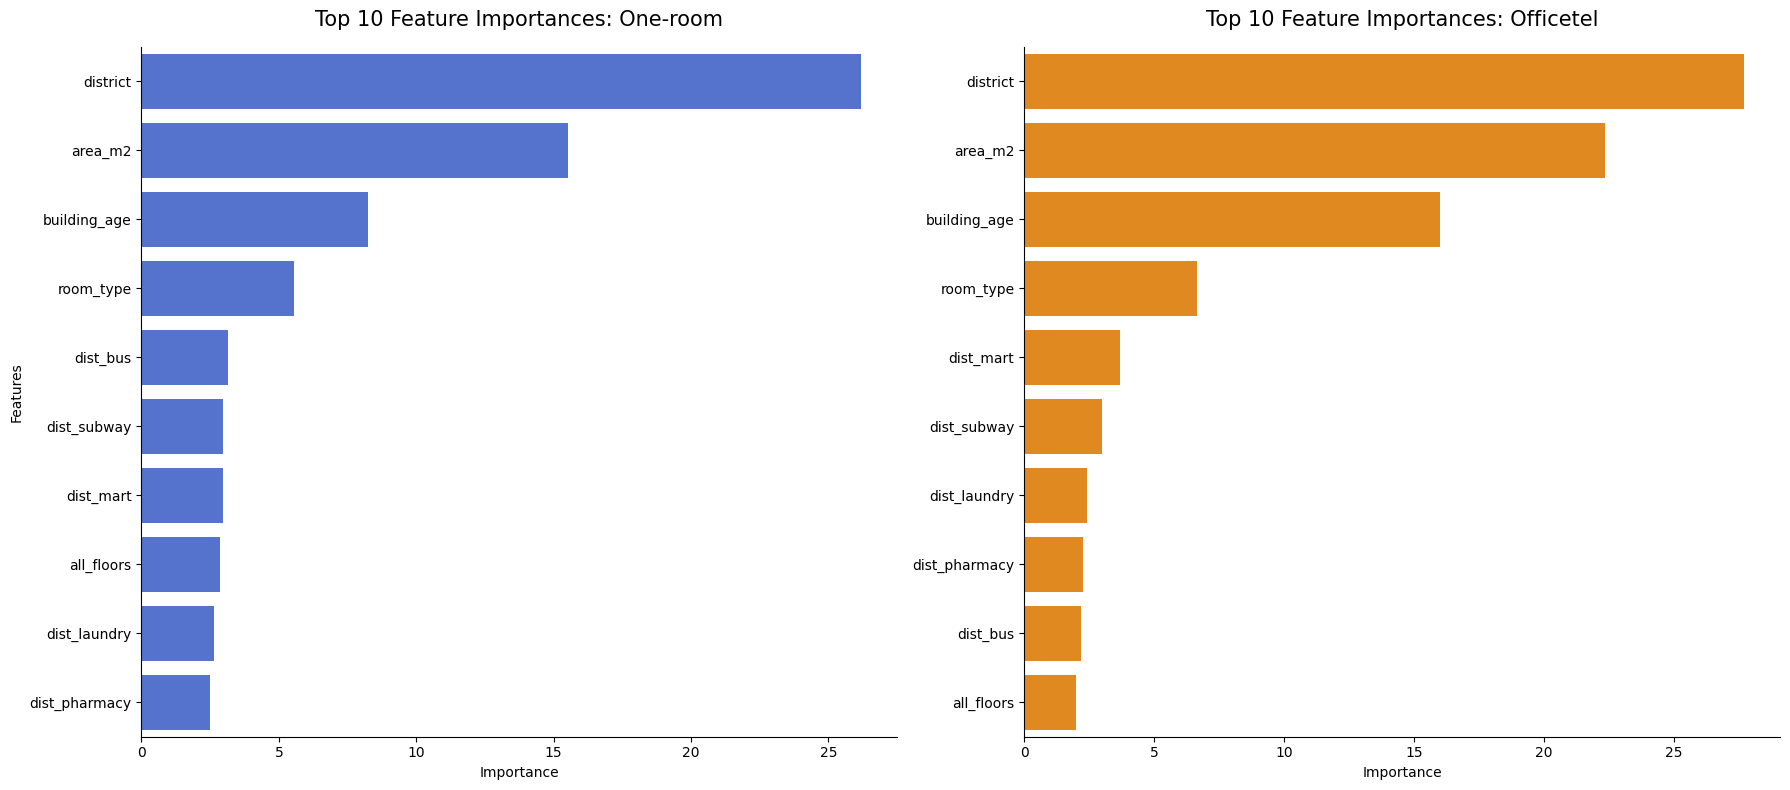

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. 데이터프레임 준비 (아까랑 동일하게 상위 10개 추출)
# df_oneroom, df_officetel이 이미 준비되어 있다고 가정할게!
# 2. 시각화 설정
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- 왼쪽: 원룸 (Blue 계열) ---
sns.barplot(x='importance', y='feature', data=df_oneroom,
            ax=axes[0], color='royalblue') # 파란색 지정
axes[0].set_title('Top 10 Feature Importances: One-room', fontsize=15, pad=15)
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Features')

# --- 오른쪽: 오피스텔 (Orange 계열) ---
sns.barplot(x='importance', y='feature', data=df_officetel,
            ax=axes[1], color='darkorange') # 주황색 지정
axes[1].set_title('Top 10 Feature Importances: Officetel', fontsize=15, pad=15)
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('') # y축 라벨 생략

# 3. 그래프 디테일 살리기
plt.tight_layout()
sns.despine() # 테두리 살짝 제거해서 더 깔끔하게

plt.show()

이상치 제거 후: (24960, 48)
0:	learn: 20.1670035	test: 20.0599887	best: 20.0599887 (0)	total: 5.61ms	remaining: 5.61s
100:	learn: 10.5707770	test: 10.5267640	best: 10.5267640 (100)	total: 671ms	remaining: 5.97s
200:	learn: 9.5467614	test: 9.7934680	best: 9.7934680 (200)	total: 1.26s	remaining: 5s
300:	learn: 8.8758273	test: 9.3937981	best: 9.3937981 (300)	total: 1.82s	remaining: 4.22s
400:	learn: 8.3758957	test: 9.1122407	best: 9.1122407 (400)	total: 2.36s	remaining: 3.53s
500:	learn: 7.9701243	test: 8.9042653	best: 8.9042653 (500)	total: 2.94s	remaining: 2.92s
600:	learn: 7.5916996	test: 8.7305973	best: 8.7305973 (600)	total: 3.53s	remaining: 2.34s
700:	learn: 7.2822203	test: 8.5772569	best: 8.5772127 (698)	total: 4.12s	remaining: 1.76s
800:	learn: 6.9829060	test: 8.4402403	best: 8.4402403 (800)	total: 4.75s	remaining: 1.18s
900:	learn: 6.6957554	test: 8.3377280	best: 8.3377280 (900)	total: 5.32s	remaining: 585ms
999:	learn: 6.4560692	test: 8.2273560	best: 8.2273560 (999)	total: 5.91s	remai